# Kepler exoplanet classification - Notebook 01

**Data exploration, leakage analysis, and cleaning**

Author: Atilla Ahmed

---

## Abstract 
This notebook prepares the NASA Kepler cumulative Object of Interest (KOI) table for downstream deep learning experiments. We characterize the dataset through exploratory analysis, identify and quantify three sources of potential label leakage that inflate accuracy in many published studies on this data, and produce clean stratified train/validation/test splits saved as parquet files. The output is three feature sets leaky, semi-leaky, and leak-free that allow us to measure how much reported model performance depends on label-adjacent features rather than genuine astrophysical signal.

## Table of contents

1. [Introduction](#1-introduction)
2. [Data loading and first look](#2-data-loading-and-first-look)
3. [Exploratory data analysis](#3-exploratory-data-analysis)
4. [Data leakage analysis](#4-data-leakage-analysis)
5. [Data cleaning](#5-data-cleaning)
6. [Train / validation / test splits](#6-train--validation--test-splits)
7. [Summary and next steps](#7-summary-and-next-steps)

## 1. Introduction
The NASA Kepler mission and its dataset of Kepler Objects of Interest (KOIs) form the empirical foundation for modern exoplanet science. Before we can meaningfully apply deep learning to this data, we must understand what the dataset represents, how it was generated, and what real-world problem our classifier is being asked to solve. This section provides that context in four parts: a brief history of the mission, a description of the transit method used to detect the signals, a formal problem statement, and the specific objectives of this notebook.

### 1.1. The Kepler mission
Тhe Kepler Space Telescope, launched by NASA in March 2009, was designed with a single scientific objective: to determine what fraction of stars in the Milky Way host Earth-sized planets in the habitable zone. Between 2009 and 2013, the telescope continuously monitored the brightness of approximately 150,000 main-sequence stars in a fixed field of view in the constellations Cygnus and Lyra.

### 1.2. Transit method for exoplanet detection
Kepler detects exoplanets through the *transit method*: when a planet passes in front of its host star from our line of sight, the star's brightness dips by a small fraction typically 0.01% to 1% for the duration of the transit. The depth of the dip is proportional to the square of the ratio of planet radius to stellar radius, and the interval between successive dips gives the orbital period.

### 1.3. Problem statement

Given the physical and observational parameters of a Kepler Object of Interest orbital period, transit depth, planet radius, stellar temperature, transit duration, and roughly 20 other features derived from photometric measurements we want to predict its true nature: a *confirmed* exoplanet, an unconfirmed *candidate* still under investigation, or a *false positive* caused by non-planetary phenomena. This is a three-class classification problem on the Kepler cumulative KOI table, with 9,564 rows and 153 candidate features.

### 1.4. Notebook objectives

By the end of this notebook we will have:

1. A characterization of the dataset through targeted exploratory analysis focused on features with clear astrophysical meaning.
2. An explicit identification of three types of label leakage present in the KOI table and a quantification of their impact.
3. Three curated feature sets leaky, semi-leaky, and leak-free that will allow subsequent modelling notebooks to distinguish genuine predictive skill from artefacts of label construction.
4. Cleaned stratified train, validation, and test splits saved as parquet files for use in downstream training.

## 2. Data loading and first look

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

warnings.filterwarnings("ignore", category=FutureWarning)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)
pd.set_option("display.precision", 4)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

DATA_PATH = Path("../data/raw/kepler_data.csv")
PROCESSED_PATH = Path("../data/processed")
FIGURES_PATH = Path("../reports/figures")

print(f"Data file exists: {DATA_PATH.exists()}")

Data file exists: True


### 2.1. Loading the dataset

In [2]:
planets = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Shape: {planets.shape[0]:,} rows x {planets.shape[1]} columns")
print(f"Memory usage: {planets.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Shape: 9,564 rows x 153 columns
Memory usage: 24.5 MB


In [3]:
planets.head()

,kepid,kepoi_name,kepler_name,ra,ra_err,ra_str,dec,dec_err,dec_str,koi_gmag,koi_gmag_err,koi_rmag,koi_rmag_err,koi_imag,koi_imag_err,koi_zmag,koi_zmag_err,koi_jmag,koi_jmag_err,koi_hmag,koi_hmag_err,koi_kmag,koi_kmag_err,koi_kepmag,koi_kepmag_err,...,koi_dikco_msky,koi_dikco_msky_err,koi_comment,koi_vet_date,koi_tce_plnt_num,koi_tce_delivname,koi_datalink_dvs,koi_disp_prov,koi_parm_prov,koi_time0,koi_time0_err1,koi_time0_err2,koi_datalink_dvr,koi_fpflag_nt,koi_fpflag_ss,koi_fpflag_co,koi_fpflag_ec,koi_insol,koi_insol_err1,koi_insol_err2,koi_srho,koi_srho_err1,koi_srho_err2,koi_fittype,koi_score
0,10797460,K00752.01,Kepler-227 b,291.9342,0.0,19h27m44.22s,48.1417,0.0,+48d08m29.9s,15.890,NaN,15.270,NaN,15.114,NaN,15.006,NaN,14.082,0.025,13.751,0.030,13.648,0.054,15.347,NaN,...,0.320,0.160,NO_COMMENT,2018-08-16,1.0,q1_q17_dr25_tce,010/010797/010797460/dv/kplr010797460-001-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2.4550e+06,0.0022,-0.0022,010/010797/010797460/dv/kplr010797460-20160209...,0,0,0,0,93.59,29.45,-16.65,3.2080,0.3317,-1.0999,LS+MCMC,1.000
1,10797460,K00752.02,Kepler-227 c,291.9342,0.0,19h27m44.22s,48.1417,0.0,+48d08m29.9s,15.890,NaN,15.270,NaN,15.114,NaN,15.006,NaN,14.082,0.025,13.751,0.030,13.648,0.054,15.347,NaN,...,0.500,0.450,NO_COMMENT,2018-08-16,2.0,q1_q17_dr25_tce,010/010797/010797460/dv/kplr010797460-002-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2.4550e+06,0.0035,-0.0035,010/010797/010797460/dv/kplr010797460-20160209...,0,0,0,0,9.11,2.87,-1.62,3.0237,2.2049,-2.4964,LS+MCMC,0.969
2,10811496,K00753.01,NaN,297.0048,0.0,19h48m01.16s,48.1341,0.0,+48d08m02.9s,15.943,NaN,15.390,NaN,15.220,NaN,15.166,NaN,14.254,0.028,13.900,0.033,13.826,0.058,15.436,NaN,...,0.027,0.074,DEEP_V_SHAPED,2018-08-16,1.0,q1_q17_dr25_tce,010/010811/010811496/dv/kplr010811496-001-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2.4550e+06,0.0006,-0.0006,010/010811/010811496/dv/kplr010811496-20160209...,0,0,0,0,39.30,31.04,-10.49,7.2956,35.0329,-2.7545,LS+MCMC,0.000
3,10848459,K00754.01,NaN,285.5346,0.0,19h02m08.31s,48.2852,0.0,+48d17m06.8s,16.100,NaN,15.554,NaN,15.382,NaN,15.266,NaN,14.326,0.035,13.911,0.042,13.809,0.048,15.597,NaN,...,0.276,0.076,MOD_ODDEVEN_DV---MOD_ODDEVEN_ALT---DEEP_V_SHAPED,2018-08-16,1.0,q1_q17_dr25_tce,010/010848/010848459/dv/kplr010848459-001-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2.4550e+06,0.0001,-0.0001,010/010848/010848459/dv/kplr010848459-20160209...,0,1,0,0,891.96,668.95,-230.35,0.2208,0.0092,-0.0184,LS+MCMC,0.000
4,10854555,K00755.01,Kepler-664 b,288.7549,0.0,19h15m01.17s,48.2262,0.0,+48d13m34.3s,16.015,NaN,15.468,NaN,15.292,NaN,15.241,NaN,14.366,0.033,14.064,0.047,13.952,0.047,15.509,NaN,...,0.070,0.200,NO_COMMENT,2018-08-16,1.0,q1_q17_dr25_tce,010/010854/010854555/dv/kplr010854555-001-2016...,q1_q17_dr25_sup_koi,q1_q17_dr25_koi,2.4550e+06,0.0011,-0.0011,010/010854/010854555/dv/kplr010854555-20160209...,0,0,0,0,926.16,874.33,-314.24,1.9864,2.7114,-1.7454,LS+MCMC,1.000


### 2.3. Column types and non-null counts

We inspect the dtypes and non-null counts to understand which columns are numeric, categorical, and how sparse each column is.

In [4]:
planets.info(verbose=False, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9564 entries, 0 to 9563
Columns: 153 entries, kepid to koi_score
dtypes: float64(127), int64(6), object(20)
memory usage: 11.2+ MB


### 2.4. Functional column groups

Not all 153 columns serve the same purpose. Before deciding what to use as model input, we categorize them into functional groups. This categorization drives the leakage analysis in Section 4 and the final feature selection in Section 5.

In [5]:
target_col = "koi_disposition"

identifier_cols = ["kepid", "kepoi_name", "kepler_name"]

coord_cols = ["ra", "ra_str", "dec", "dec_str"]

target_related_cols = [
    "koi_pdisposition",
    "koi_score",
    "koi_disp_prov",
    "koi_vet_stat",
    "koi_vet_date",
    "koi_comment",
]

fp_flag_cols = [
    "koi_fpflag_nt",
    "koi_fpflag_ss",
    "koi_fpflag_co",
    "koi_fpflag_ec",
]

metadata_cols = [
    "koi_delivname",
    "koi_quarters",
    "koi_tce_plnt_num",
    "koi_tce_delivname",
    "koi_datalink_dvs",
    "koi_datalink_dvr",
    "koi_parm_prov",
    "koi_sparprov",
    "koi_limbdark_mod",
    "koi_trans_mod",
    "koi_fittype",
]
error_cols = [c for c in planets.columns if c.endswith("_err") or c.endswith("_err1") or c.endswith("_err2")]
categorized = set(
    [target_col]
    + identifier_cols
    + coord_cols
    + target_related_cols
    + fp_flag_cols
    + metadata_cols
    + error_cols
)

physical_cols = [c for c in planets.columns if c not in categorized]

print(f"Target column:        1  ({target_col})")
print(f"Identifier columns:   {len(identifier_cols)}")
print(f"Coordinate columns:   {len(coord_cols)}")
print(f"Target-related:       {len(target_related_cols)}")
print(f"False positive flags: {len(fp_flag_cols)}")
print(f"Metadata columns:     {len(metadata_cols)}")
print(f"Error columns:        {len(error_cols)}")
print(f"Physical measurements: {len(physical_cols)}")
print(f"Total:                {1 + len(identifier_cols) + len(coord_cols) + len(target_related_cols) + len(fp_flag_cols) + len(metadata_cols) + len(error_cols) + len(physical_cols)}")


Target column:        1  (koi_disposition)
Identifier columns:   3
Coordinate columns:   4
Target-related:       6
False positive flags: 4
Metadata columns:     11
Error columns:        68
Physical measurements: 56
Total:                153


### 2.5. Target variable overview

The target `koi_disposition` takes three values: `CONFIRMED` for verified exoplanets, `CANDIDATE` for KOIs still under investigation, and `FALSE POSITIVE` for signals attributed to non-planetary phenomena. We examine the class distribution to assess balance.

In [6]:
class_counts = planets[target_col].value_counts()
class_pct = planets[target_col].value_counts(normalize=True) * 100

target_summary = pd.DataFrame({
    "count": class_counts,
    "percentage": class_pct.round(1),
})

print(target_summary)

                 count  percentage
koi_disposition                   
FALSE POSITIVE    4839        50.6
CONFIRMED         2747        28.7
CANDIDATE         1978        20.7


The class distribution shows moderate imbalance. `FALSE POSITIVE` dominates at 50.6%, while `CANDIDATE` is the smallest class at 20.7%. A trivial classifier that always predicts `FALSE POSITIVE` would achieve 50.6% accuracy, which sets a hard lower bound for meaningful models.

### 2.6. Key findings from initial exploration

- The KOI table contains **9,564 rows and 153 columns**, of which 56 are physical measurements potentially usable as features, 68 are error terms for those measurements, and the remainder are identifiers, coordinates, and provenance metadata.
- The target `koi_disposition` has **three classes with moderate imbalance** (50.6% / 28.7% / 20.7%).

In [7]:
planets.isnull().sum()

kepid               0
kepoi_name          0
kepler_name      6817
ra                  0
ra_err              0
                 ... 
koi_srho          321
koi_srho_err1     321
koi_srho_err2     321
koi_fittype         0
koi_score        1510
Length: 153, dtype: int64

## 3. Exploratory data analysis

Having categorized the columns and confirmed the target distribution, we now examine the data visually. This section focuses on the physical measurements that describe each Kepler Object of Interest — orbital period, transit depth, planet radius, and the stellar parameters of the host star — and inspects missing values, feature distributions, and correlations that will inform cleaning decisions in Section 5.

### 3.1. Class distribution

We visualize the class distribution to complement the numerical summary from Section 2.5. A bar chart makes the imbalance immediately visible and provides a reference point for later calibration analysis.

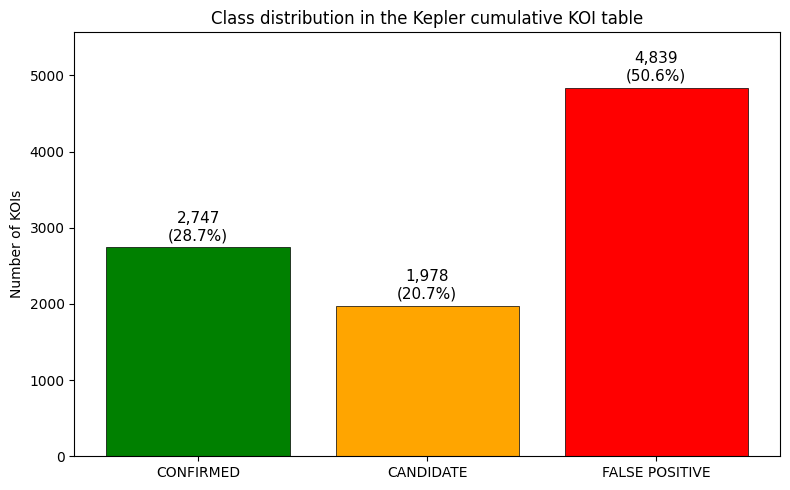

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
class_order = ["CONFIRMED", "CANDIDATE", "FALSE POSITIVE"]
colors = ["green", "orange", "red"]
counts = planets[target_col].value_counts().reindex(class_order)
bars = ax.bar(class_order, counts.values, color=colors, edgecolor="black", linewidth=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / counts.sum() * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 50,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11,
    )

ax.set_ylabel("Number of KOIs")
ax.set_title("Class distribution in the Kepler cumulative KOI table")
ax.set_ylim(0, counts.max() * 1.15)

plt.tight_layout()
plt.show()

The bar chart confirms the numerical summary: `FALSE POSITIVE` is the majority class with 4,839 objects (50.6%), followed by `CONFIRMED` at 2,747 (28.7%) and `CANDIDATE` at 1,978 (20.7%). The imbalance is moderate but non-trivial a naive classifier predicting always `FALSE POSITIVE` would achieve 50.6% accuracy. This motivates the use of macro-F1 as the primary evaluation metric in Notebook 02.

### 3.2. Missing values analysis

Before choosing an imputation strategy in Section 5, we need to understand the extent and structure of missing data. We compute the missing percentage per column, then look at how the gaps distribute across the functional groups defined in Section 2.4.

In [9]:
missing_counts = planets.isna().sum()
missing_pct = (missing_counts / len(planets) * 100).round(1)

missing_summary = pd.DataFrame({
    "n_missing": missing_counts,
    "pct_missing": missing_pct,
}).sort_values("pct_missing", ascending=False)

print(f"Columns with 100% missing:  {(missing_pct == 100).sum()}")
print(f"Columns with >50% missing:  {(missing_pct > 50).sum()}")
print(f"Columns with >10% missing:  {(missing_pct > 10).sum()}")
print(f"Columns with any missing:   {(missing_pct > 0).sum()}")
print(f"Columns with no missing:    {(missing_pct == 0).sum()}")

Columns with 100% missing:  24
Columns with >50% missing:  25
Columns with >10% missing:  33
Columns with any missing:   127
Columns with no missing:    26


In [10]:
print(f"Top 15 columns with most missing values:\n")
print(missing_summary.head(15))

Top 15 columns with most missing values:

                 n_missing  pct_missing
koi_model_chisq       9564        100.0
koi_imag_err          9564        100.0
koi_kepmag_err        9564        100.0
koi_sage_err2         9564        100.0
koi_eccen_err1        9564        100.0
koi_eccen_err2        9564        100.0
koi_longp             9564        100.0
koi_longp_err1        9564        100.0
koi_longp_err2        9564        100.0
koi_sage_err1         9564        100.0
koi_zmag_err          9564        100.0
koi_sage              9564        100.0
koi_sma_err1          9564        100.0
koi_rmag_err          9564        100.0
koi_sma_err2          9564        100.0


In [11]:
# I will lok for missing values in physical features it is more important for me 
physical_missing = missing_summary.loc[physical_cols].sort_values("pct_missing", ascending=False)

print(f"Physical features with any missing:  {(physical_missing['pct_missing'] > 0).sum()} of {len(physical_cols)}")
print(f"Physical features with >10% missing: {(physical_missing['pct_missing'] > 10).sum()}")
print(f"Physical features with >50% missing: {(physical_missing['pct_missing'] > 50).sum()}\n")

print("Top 10 physical features with most missing:")
print(physical_missing.head(10))

Physical features with any missing:  50 of 56
Physical features with >10% missing: 10
Physical features with >50% missing: 5

Top 10 physical features with most missing:
                  n_missing  pct_missing
koi_ingress            9564        100.0
koi_longp              9564        100.0
koi_model_chisq        9564        100.0
koi_model_dof          9564        100.0
koi_sage               9564        100.0
koi_bin_oedp_sig       1510         15.8
koi_max_mult_ev        1142         11.9
koi_num_transits       1142         11.9
koi_max_sngle_ev       1142         11.9
koi_fwm_stat_sig       1076         11.3


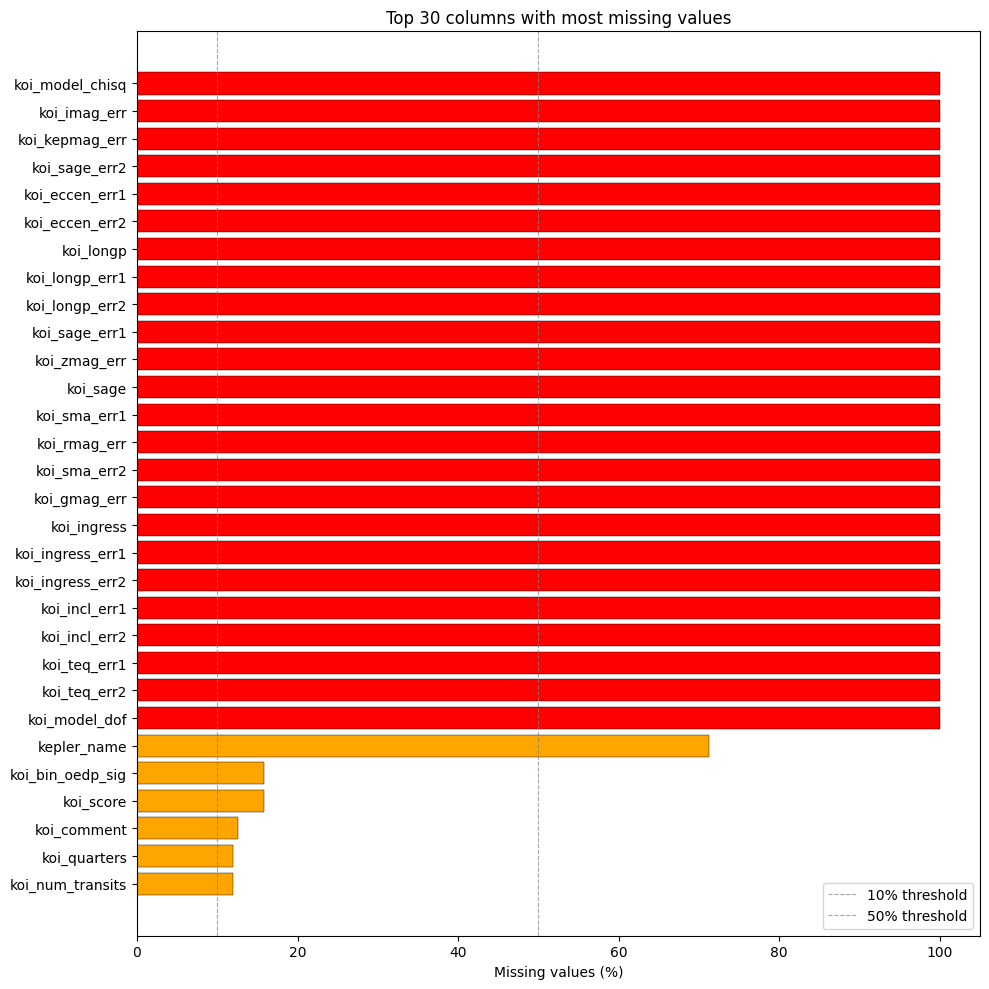

In [12]:
top_missing = missing_summary[missing_summary["pct_missing"] > 0].head(30)

fig, ax = plt.subplots(figsize=(10, 10))

colors_bar = ["red" if pct == 100 else "orange" if pct > 10 else "steelblue" for pct in top_missing["pct_missing"]]

ax.barh(top_missing.index[::-1], top_missing["pct_missing"][::-1], color=colors_bar[::-1], edgecolor="black", linewidth=0.3)

ax.set_xlabel("Missing values (%)")
ax.set_title("Top 30 columns with most missing values")
ax.axvline(x=10, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="10% threshold")
ax.axvline(x=50, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="50% threshold")
ax.set_xlim(0, 105)
ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

he missing values fall into three clear groups. First, 24 columns are entirely empty (red) — these include chi-square diagnostics (`koi_model_chisq`, `koi_model_dof`), error terms that NASA does not compute (`_err`, `_err1`, `_err2` variants), and physical parameters computed only for special cases (`koi_longp`, `koi_sage`, `koi_eccen`, `koi_ingress`). These 24 columns will be dropped without further analysis in Section 5.

Second, `kepler_name` is missing for 71.3% of rows — precisely for the `FALSE POSITIVE` and `CANDIDATE` classes, which by definition do not receive Kepler designations. This column is target-related and will be discussed in Section 4.

Third, six physical measurements have moderate missing rates of 11–16% (`koi_bin_oedp_sig`, `koi_num_transits`, `koi_max_mult_ev`, `koi_max_sngle_ev`, `koi_fwm_stat_sig`, `koi_score`). These will be imputed using column-wise median with a binary "was missing" indicator column, following standard practice for tabular deep learning.

### 3.3. Distributions of key physical features

We examine the distributions of features with clear astrophysical meaning, split by disposition class. Differences in these distributions between confirmed exoplanets and false positives provide intuition about what the models will learn.

#### 3.3.1. Orbital Period 

The orbital period is the time it takes the object to complete one orbit around its host star. Since Kepler observed for approximately 3.5 years, planets with very long periods would show few or no transits and are harder to detect reliably. We use a log scale on the x-axis because periods span many orders of magnitude, from hours to years.

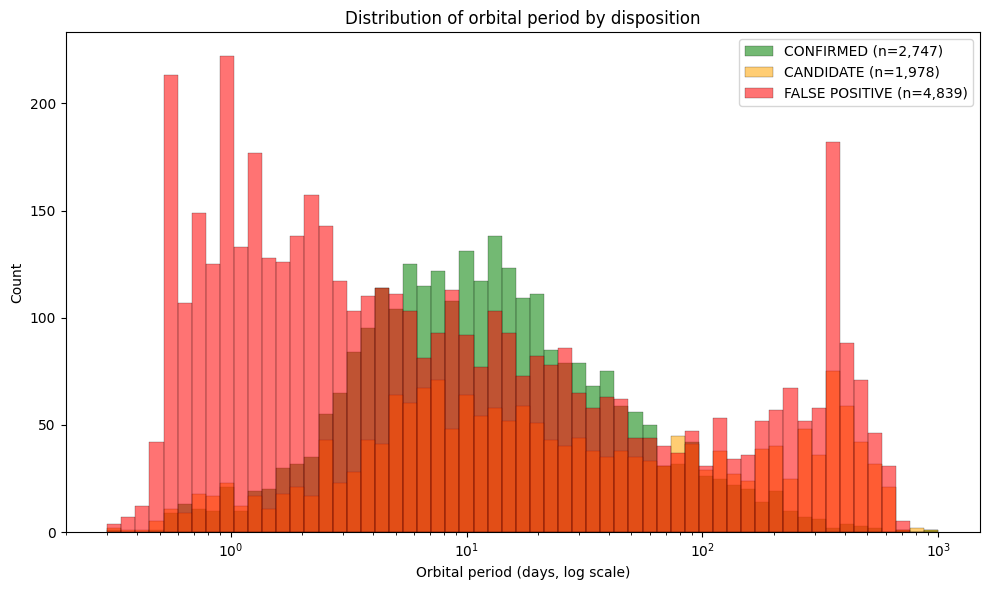

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.logspace(np.log10(0.3), np.log10(1000), 60)

for cls, color in zip(class_order, colors):
    subset = planets.loc[planets[target_col] == cls, "koi_period"].dropna()
    subset = subset[subset > 0]
    ax.hist(subset, bins=bins, alpha=0.55, label=f"{cls} (n={len(subset):,})", color=color, edgecolor="black", linewidth=0.3)

ax.set_xscale("log")
ax.set_xlabel("Orbital period (days, log scale)")
ax.set_ylabel("Count")
ax.set_title("Distribution of orbital period by disposition")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

The distributions reveal clear astrophysical structure. `FALSE POSITIVE` (red) shows two prominent peaks: one at very short periods below 1 day, characteristic of eclipsing binary stars, and one near 372 days — a well-known systematic artifact of the Kepler pipeline caused by Earth's orbital motion. `CONFIRMED` planets (green) cluster in the 5–30 day range, with a sharp cutoff beyond 100 days. `CANDIDATE` objects (orange) show a broader distribution overlapping with confirmed planets, consistent with their status as promising but not yet verified detections.

This distributional structure is exactly the signal deep learning models will exploit

#### 3.3.2. Transit depth

Transit depth is the fractional decrease in stellar brightness when the object passes in front of the star, measured in parts per million (ppm). Physically, depth scales as the square of the ratio of object radius to stellar radius. Small planets produce shallow transits (tens to hundreds of ppm), while eclipsing binary stars produce depths of thousands to tens of thousands of ppm. Depth is therefore one of the most discriminative features between planetary and stellar false positives.

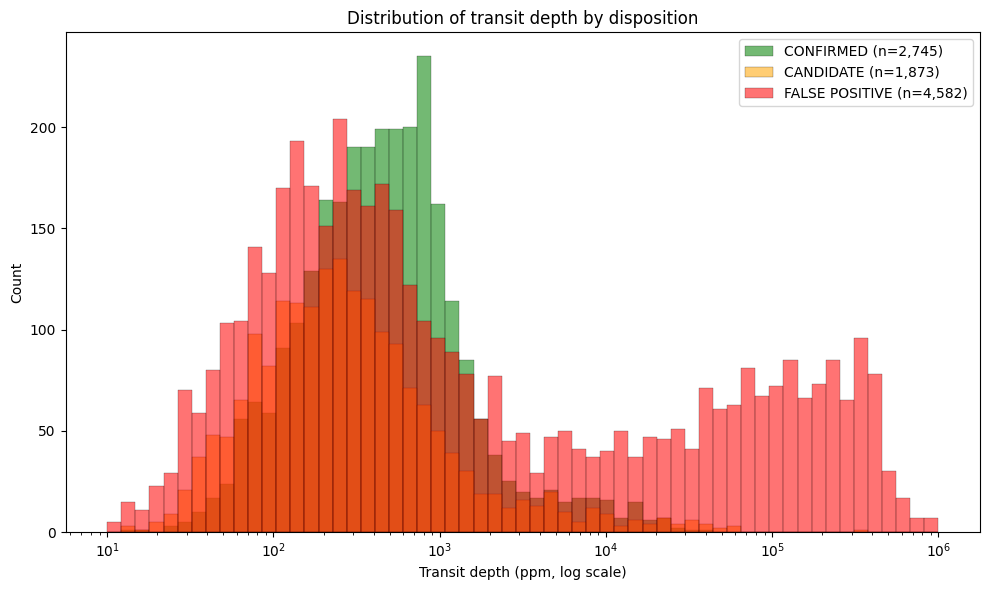

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.logspace(np.log10(10), np.log10(1e6), 60)
for cls, color in zip(class_order, colors):
    subset = planets.loc[planets[target_col] == cls, "koi_depth"].dropna()
    subset = subset[subset > 0]
    ax.hist(subset, bins=bins, alpha=0.55, label=f"{cls} (n={len(subset):,})", color=color, edgecolor="black", linewidth=0.3)

ax.set_xscale("log")
ax.set_xlabel("Transit depth (ppm, log scale)")
ax.set_ylabel("Count")
ax.set_title("Distribution of transit depth by disposition")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

The distribution is bimodal. `CONFIRMED` and `CANDIDATE` overlap almost entirely in the 100–1,000 ppm range, consistent with planetary transits (an Earth around a Sun-like star produces ~85 ppm, a Jupiter ~10,000 ppm).

`FALSE POSITIVE` has a second peak between 10,000 and 1,000,000 ppm, physically impossible for a real planet and characteristic of eclipsing binary stars. This peak is one of the strongest single-feature signals in the dataset.

The overlap between `CONFIRMED` and `CANDIDATE` suggests candidates are physically similar to confirmed planets, differing mainly in follow-up observation status.

#### 3.3.3. Planet radius

Planet radius is derived from transit depth and stellar radius. It is expressed in Earth radii, where 1 R⊕ ≈ 6,371 km and Jupiter is ~11 R⊕. Radii above ~15 R⊕ are physically implausible for planets and typically indicate eclipsing binaries.

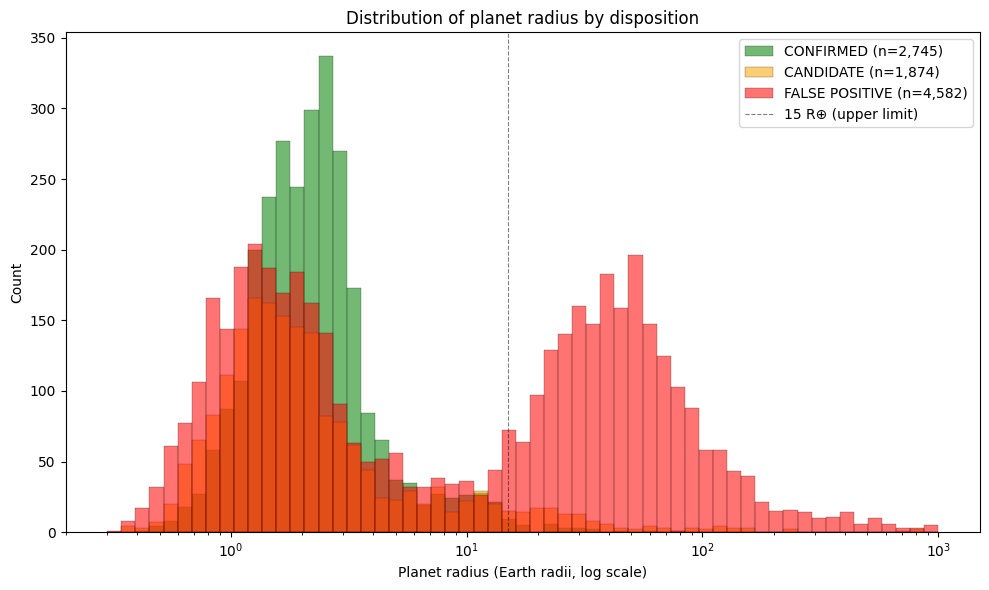

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))
bins = np.logspace(np.log10(0.3), np.log10(1000), 60)
for cls, color in zip(class_order, colors):
    subset = planets.loc[planets[target_col] == cls, "koi_prad"].dropna()
    subset = subset[subset > 0]
    ax.hist(subset, bins=bins, alpha=0.55, label=f"{cls} (n={len(subset):,})", color=color, edgecolor="black", linewidth=0.3)

ax.set_xscale("log")
ax.set_xlabel("Planet radius (Earth radii, log scale)")
ax.set_ylabel("Count")
ax.axvline(x=15, color="black", linestyle="--", linewidth=0.8, alpha=0.5, label="15 R⊕ (upper limit)")
ax.set_title("Distribution of planet radius by disposition")
ax.legend(loc="upper right")

plt.tight_layout()
plt.show()

The distribution splits cleanly at ~15 R⊕. `CONFIRMED` planets peak at 1–3 R⊕ (super-Earths and mini-Neptunes), while `FALSE POSITIVE` shows a large secondary peak around 30–100 R⊕ sizes physically impossible for planets and consistent with eclipsing binary stars.

#### 3.3.4. Host star parameters

The properties of the host star matter because transit depth depends on the star's radius. We look at effective temperature (`koi_steff`) and stellar radius (`koi_srad`)

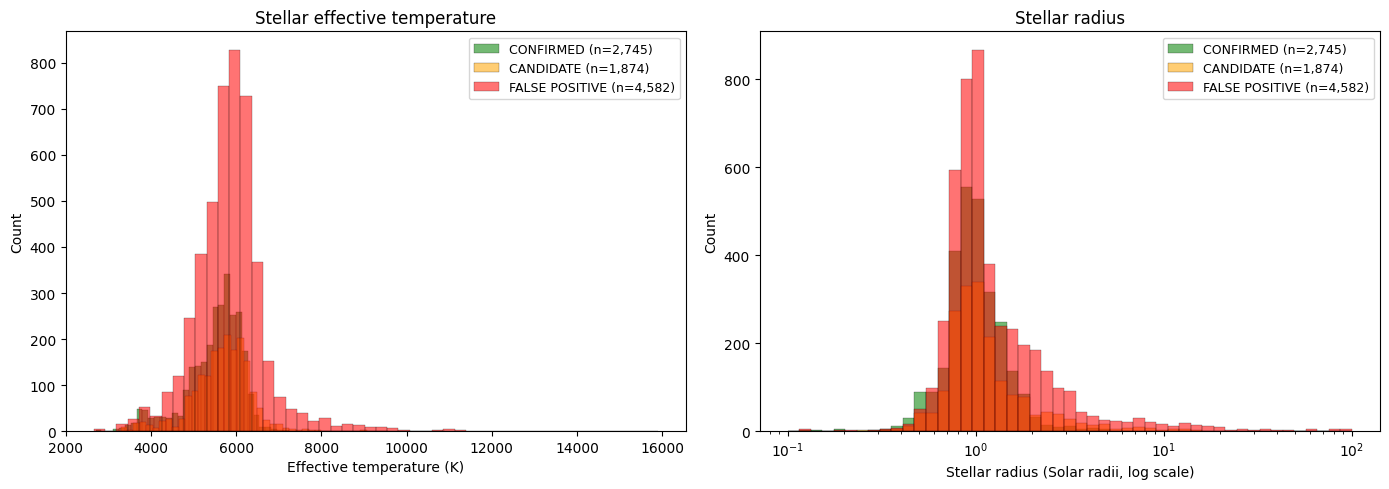

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cls, color in zip(class_order, colors):
    subset = planets.loc[planets[target_col] == cls, "koi_steff"].dropna()
    axes[0].hist(subset, bins=50, alpha=0.55, label=f"{cls} (n={len(subset):,})", color=color, edgecolor="black", linewidth=0.3)

axes[0].set_xlabel("Effective temperature (K)")
axes[0].set_ylabel("Count")
axes[0].set_title("Stellar effective temperature")
axes[0].legend(loc="upper right", fontsize=9)

bins_srad = np.logspace(np.log10(0.1), np.log10(100), 50)
for cls, color in zip(class_order, colors):
    subset = planets.loc[planets[target_col] == cls, "koi_srad"].dropna()
    subset = subset[subset > 0]
    axes[1].hist(subset, bins=bins_srad, alpha=0.55, label=f"{cls} (n={len(subset):,})", color=color, edgecolor="black", linewidth=0.3)

axes[1].set_xscale("log")
axes[1].set_xlabel("Stellar radius (Solar radii, log scale)")
axes[1].set_ylabel("Count")
axes[1].set_title("Stellar radius")
axes[1].legend(loc="upper right", fontsize=9)

plt.tight_layout()
plt.show()

Unlike orbital period, transit depth, and planet radius, the stellar parameters do not visually separate the classes. This does not mean they are useless models will learn feature interactions

### 3.4. Feature correlations

We compute pairwise correlations across the 56 physical features to identify redundant pairs and highlight groups of features that measure related physical quantities.

In [17]:
numeric_physical = planets[physical_cols].select_dtypes(include=[np.number])
numeric_physical = numeric_physical.dropna(axis=1, how="all")

corr_matrix = numeric_physical.corr()


corr_pairs = corr_matrix.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0]
corr_pairs = corr_pairs[~corr_pairs.index.get_level_values(0).duplicated() | ~corr_pairs.index.get_level_values(1).duplicated()]

seen = set()
top_pairs = []
for (a, b), val in corr_pairs.items():
    pair = frozenset([a, b])
    if pair not in seen:
        seen.add(pair)
        actual_corr = corr_matrix.loc[a, b]
        top_pairs.append((a, b, actual_corr))
    if len(top_pairs) >= 15:
        break

top_pairs_df = pd.DataFrame(top_pairs, columns=["feature_1", "feature_2", "correlation"])
print("Top 15 feature correlations (by absolute value):\n")
print(top_pairs_df.to_string(index=False))

Top 15 feature correlations (by absolute value):

       feature_1       feature_2  correlation
       koi_time0     koi_time0bk       1.0000
      koi_kepmag        koi_rmag       0.9993
        koi_hmag        koi_kmag       0.9978
        koi_zmag        koi_imag       0.9974
        koi_zmag        koi_jmag       0.9950
         koi_ror      koi_impact       0.9944
      koi_period         koi_dor       0.9894
        koi_gmag        koi_rmag       0.9862
  koi_ldm_coeff2  koi_ldm_coeff1      -0.9654
  koi_dikco_mdec  koi_dicco_mdec       0.9017
  koi_dicco_msky  koi_dikco_msky       0.8960
   koi_dikco_mra   koi_dicco_mra       0.8930
         koi_dor         koi_sma       0.8864
koi_max_sngle_ev koi_max_mult_ev       0.8685
       koi_steff  koi_ldm_coeff1      -0.7371


The correlation analysis reveals several redundant feature groups.
Correlated features are not harmful for deep learning models attention mechanisms and neural nets handle redundancy gracefully. However, they inflate the effective feature count.

### 3.5. Key findings from EDA

- **Class imbalance is moderate** (50.6% FALSE POSITIVE, 28.7% CONFIRMED, 20.7% CANDIDATE) — macro-F1 will be the primary metric to prevent bias toward the majority class.
- **Missing values are structured**: 24 columns are entirely empty, 6 physical features have moderate missing rates (11–16%). Section 5 will drop the empty columns and impute the moderately missing ones with median plus binary indicator.
- **Physical features carry strong class signal**: transit depth and planet radius separate `FALSE POSITIVE` (eclipsing binaries) from planetary candidates almost cleanly, while stellar parameters contribute mainly through feature interactions.
- **CONFIRMED and CANDIDATE are physically similar** — they overlap in every distribution examined, differing primarily in follow-up observation status rather than intrinsic properties.
- **Feature redundancy is high**: several photometric and geometric feature groups have correlations above 0.9. Deep learning models handle this natively, but obvious duplicates will be dropped in Section 5.

## 4. Data leakage analysis

Six columns in the KOI table are derived from or closely related to the labelling process itself. Using them as model features would inflate accuracy without teaching the model any real astrophysics. This section identifies them, measures their impact empirically, and defines three feature sets that will be compared in Notebook 02.

### 4.1. Suspicius columns identified

We examine six columns that are directly derived from the vetting and disposition process, then explain why each is problematic.

In [18]:
leaky_info = pd.DataFrame([
    ("koi_score",       "NASA-computed probability of being a real planet (0–1)"),
    ("koi_pdisposition","Preliminary disposition assigned by NASA pipeline"),
    ("koi_fpflag_nt",   "False positive flag: not transit-like"),
    ("koi_fpflag_ss",   "False positive flag: stellar eclipse"),
    ("koi_fpflag_co",   "False positive flag: centroid offset"),
    ("koi_fpflag_ec",   "False positive flag: ephemeris match"),
], columns=["column", "description"])

print(leaky_info.to_string(index=False))

          column                                            description
       koi_score NASA-computed probability of being a real planet (0–1)
koi_pdisposition      Preliminary disposition assigned by NASA pipeline
   koi_fpflag_nt                  False positive flag: not transit-like
   koi_fpflag_ss                   False positive flag: stellar eclipse
   koi_fpflag_co                   False positive flag: centroid offset
   koi_fpflag_ec                   False positive flag: ephemeris match


### 4.2. Emperical impact

To quantify how much accuracy comes from label-adjacent features versus real astrophysics, we train a quick XGBoost classifier under three feature configurations and compare validation accuracy.


In [19]:
le = LabelEncoder()
y = le.fit_transform(planets[target_col])
numerical_all = planets.select_dtypes(include=[np.number]).columns.tolist()
setup_a_features = [c for c in numerical_all if c != target_col]
setup_b_features = [c for c in setup_a_features if c != "koi_score"]
setup_c_features = [c for c in setup_b_features if c not in fp_flag_cols]
setups = {
    "A (leaky, all features)":       setup_a_features,
    "B (without koi_score)":         setup_b_features,
    "C (without fp flags)":          setup_c_features,
}

results = []
for name, features in setups.items():
    X = planets[features].fillna(planets[features].median(numeric_only=True))
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_SEED)
    model = XGBClassifier(n_estimators=100, max_depth=4, random_state=RANDOM_SEED, verbosity=0)
    model.fit(X_train, y_train)
    acc = model.score(X_val, y_val)
    results.append({"setup": name, "n_features": len(features), "val_accuracy": acc})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                  setup  n_features  val_accuracy
A (leaky, all features)         133        0.9420
  B (without koi_score)         132        0.9409
   C (without fp flags)         128        0.8646


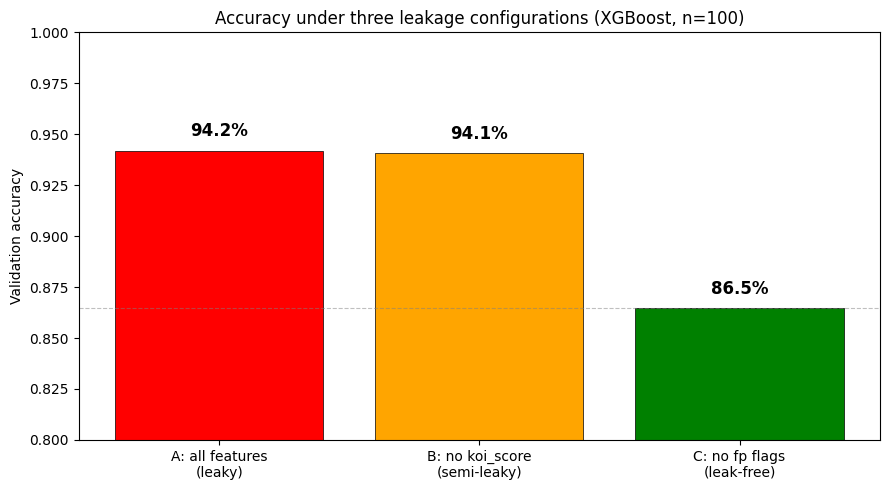

In [20]:
# Visualization 
fig, ax = plt.subplots(figsize=(9, 5))

setup_labels = ["A: all features\n(leaky)", "B: no koi_score\n(semi-leaky)", "C: no fp flags\n(leak-free)"]
colors_bar = ["red", "orange", "green"]

bars = ax.bar(setup_labels, results_df["val_accuracy"], color=colors_bar, edgecolor="black", linewidth=0.5)

for bar, acc in zip(bars, results_df["val_accuracy"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f"{acc*100:.1f}%", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylabel("Validation accuracy")
ax.set_title("Accuracy under three leakage configurations (XGBoost, n=100)")
ax.set_ylim(0.8, 1.0)
ax.axhline(y=results_df["val_accuracy"].iloc[2], color="gray", linestyle="--", linewidth=0.8, alpha=0.5)

plt.tight_layout()
plt.show()

Removing `koi_score` alone barely changes accuracy (94.2% → 94.1%) because its information is redundantly encoded in the false-positive flags. Removing the four flags collapses accuracy to 86.5% a 7.6-point drop that quantifies exactly how much reported performance in this dataset comes from label-adjacent features versus real astrophysical signal.

### 4.3. Three feature sets defined

We formalize the three configurations as ordered lists for use in Notebook 02. Setup C is the primary configuration; Setup A and B serve as diagnostic upper bounds.

In [21]:
feature_sets = {
    "setup_a_leaky": setup_a_features,
    "setup_b_semi_leaky": setup_b_features,
    "setup_c_leak_free": setup_c_features
}
for name, features in feature_sets.items():
    print(f"{name}: {len(features)} features")

setup_a_leaky: 133 features
setup_b_semi_leaky: 132 features
setup_c_leak_free: 128 features


## 5. Data cleaning and splitting

We apply the decisions from the previous sections: drop empty and non-feature columns, encode the target, create stratified train/validation/test splits, and impute missing values using only training-set statistics to avoid leakage into evaluation.

### 5.1. Drop empty and non-feature columns

We drop three groups: columns with 100% missing values, identifier columns that carry no astrophysical signal, and raw metadata not usable for modelling.

In [22]:
fully_empty_cols = missing_pct[missing_pct == 100].index.tolist()
cols_to_drop = list(set(
    fully_empty_cols
    + identifier_cols
    + coord_cols 
    + metadata_cols
    + [c for c in target_related_cols if c != "koi_pdisposition"]
))
cols_to_drop = [c for c in cols_to_drop if c in planets.columns and c != target_col]

planets_clean = planets.drop(columns=cols_to_drop).copy()

print(f"Original columns:      {planets.shape[1]}")
print(f"Columns dropped:       {len(cols_to_drop)}")
print(f"Remaining columns:     {planets_clean.shape[1]}")

Original columns:      153
Columns dropped:       47
Remaining columns:     106


### 5.2. Drop error columns

Error columns (`_err`, `_err1`, `_err2` suffixes) contain measurement uncertainties. They rarely improve predictive performance for the disposition task and inflate the feature count. We drop them to keep the model input focused on the measurements themselves.

In [23]:
error_cols_remaining = [c for c in planets_clean.columns if c.endswith("_err") or c.endswith("_err1") or c.endswith("_err2")]

planets_clean = planets_clean.drop(columns=error_cols_remaining)

print(f"Error columns dropped: {len(error_cols_remaining)}")
print(f"Remaining columns:     {planets_clean.shape[1]}")

Error columns dropped: 49
Remaining columns:     57


### 5.3. Encode the target

We encode the three disposition classes as integers so downstream models can consume them directly: `CONFIRMED` → 0, `CANDIDATE` → 1, `FALSE POSITIVE` → 2.

In [24]:
class_to_int = {"CONFIRMED": 0, "CANDIDATE": 1, "FALSE POSITIVE": 2}
int_to_class = {v: k for k, v in class_to_int.items()}
planets_clean["target"] = planets_clean[target_col].map(class_to_int)
planets_clean = planets_clean.drop(columns=[target_col])

print(planets_clean["target"].value_counts().sort_index())
print(f"\nMapping: {class_to_int}")

target
0    2747
1    1978
2    4839
Name: count, dtype: int64

Mapping: {'CONFIRMED': 0, 'CANDIDATE': 1, 'FALSE POSITIVE': 2}


### 5.4. Stratified train / validation / test split

We split the data into 70% train, 15% validation, and 15% test, stratified by the target so that all three subsets preserve the original class proportions. The random seed is fixed for reproducibility.

In [25]:
y = planets_clean["target"]
X = planets_clean.drop(columns=["target"])

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=RANDOM_SEED
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, stratify=y_temp, random_state=RANDOM_SEED
)

print(f"Train:      {len(X_train):>5} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation: {len(X_val):>5} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test:       {len(X_test):>5} ({len(X_test)/len(X)*100:.1f}%)")
print(f"Total:      {len(X_train) + len(X_val) + len(X_test):>5}")

Train:       6694 (70.0%)
Validation:  1435 (15.0%)
Test:        1435 (15.0%)
Total:       9564


In [26]:
# quick check for stratification - class distribution is the same in the three subsets
strat_check = pd.DataFrame({
    "train":      y_train.value_counts(normalize=True).sort_index(),
    "validation": y_val.value_counts(normalize=True).sort_index(),
    "test":       y_test.value_counts(normalize=True).sort_index(),
}).round(3) * 100

strat_check.index = [int_to_class[i] for i in strat_check.index]
strat_check.columns = ["train %", "val %", "test %"]

print(strat_check)

                train %  val %  test %
CONFIRMED          28.7   28.7    28.7
CANDIDATE          20.7   20.7    20.7
FALSE POSITIVE     50.6   50.6    50.6


### 5.5. Impute missing values using training statistics

We use scikit-learn's `ColumnTransformer` composing `SimpleImputer(strategy="median", add_indicator=True)` to impute the missing physical measurements.

In [27]:
cols_with_missing = sorted(set(X_train.columns[X_train.isna().any()].tolist()) 
                           | set(X_val.columns[X_val.isna().any()].tolist()) 
                           | set(X_test.columns[X_test.isna().any()].tolist()))

preprocessor = ColumnTransformer(
    transformers=[
        ("impute", SimpleImputer(strategy="median", add_indicator=True), cols_with_missing),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False,
)

preprocessor.set_output(transform="pandas")
preprocessor.fit(X_train)

X_train = preprocessor.transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

print(f"Columns with missing (imputed): {len(cols_with_missing)}")
print(f"Feature count after imputation: {X_train.shape[1]}")
print(f"Train NaN remaining: {X_train.isna().sum().sum()}")
print(f"Val NaN remaining: {X_val.isna().sum().sum()}")
print(f"Test NaN remaining: {X_test.isna().sum().sum()}")

Columns with missing (imputed): 46
Feature count after imputation: 101
Train NaN remaining: 0
Val NaN remaining: 0
Test NaN remaining: 0


### 5.6. Save processed data

We save the three splits as parquet files together with the target column. Parquet preserves dtypes exactly (unlike CSV) and is 5–10× smaller. The feature-set definitions from Section 4.3 are saved as JSON so Notebook 02 can load them directly.

In [28]:
train_df = X_train.copy()
train_df["target"] = y_train.values

val_df = X_val.copy()
val_df["target"] = y_val.values

test_df = X_test.copy()
test_df["target"] = y_test.values

PROCESSED_PATH.mkdir(parents=True, exist_ok=True)

train_df.to_parquet(PROCESSED_PATH / "train.parquet", index=False)
val_df.to_parquet(PROCESSED_PATH / "val.parquet", index=False)
test_df.to_parquet(PROCESSED_PATH / "test.parquet", index=False)

feature_sets_to_save = {
    name: [c for c in features if c in X_train.columns]
    for name, features in feature_sets.items()
}
feature_sets_to_save["all_features"] = X_train.columns.tolist()

with open(PROCESSED_PATH / "feature_sets.json", "w") as f:
    json.dump(feature_sets_to_save, f, indent=2)

print(f"Saved to {PROCESSED_PATH.resolve()}")
print(f"  train.parquet:      {train_df.shape}")
print(f"  val.parquet:        {val_df.shape}")
print(f"  test.parquet:       {test_df.shape}")
print(f"  feature_sets.json:  {len(feature_sets_to_save)} sets")

Saved to /home/atilla/projects/kepler-exoplanet-dl/data/processed
  train.parquet:      (6694, 102)
  val.parquet:        (1435, 102)
  test.parquet:       (1435, 102)
  feature_sets.json:  4 sets


## 6. Summary and next steps

This notebook transformed the raw NASA Kepler cumulative KOI table into a clean, split, imputed dataset ready for deep learning experiments. The main outcomes:

- **9,564 objects** across three disposition classes (`CONFIRMED`, `CANDIDATE`, `FALSE POSITIVE`) with moderate class imbalance (50.6 / 28.7 / 20.7).
- **Data leakage was explicitly quantified**: removing `koi_score` and the four false-positive flags reduces XGBoost validation accuracy from 94.2% to 86.5%, exposing the difference between reported and honest performance on this dataset.
- **Three feature sets** are defined and saved: `setup_a_leaky` (all features), `setup_b_semi_leaky` (without `koi_score`), and `setup_c_leak_free` (without flags). Setup C is the primary configuration for evaluating deep learning models.
- **Cleaning pipeline**: 24 empty columns and 49 error columns were dropped, 46 remaining features with 11–16% missing rates were imputed with training-set medians using `ColumnTransformer` + `SimpleImputer(add_indicator=True)`, adding binary "was missing" indicators so models can learn from the absence itself.
- **Stratified splits**: 70/15/15 train/validation/test, class proportions preserved to within 0.1 percentage points, saved as parquet in `data/processed/` for reproducible loading.

Notebook 02 will consume `train.parquet`, `val.parquet`, `test.parquet`, and `feature_sets.json` directly, train classical baselines (Logistic Regression, Random Forest, XGBoost) and four deep learning architectures (MLP, 1D-CNN, FT-Transformer, TabNet), and compare their performance under all three leakage configurations.